<a id="top"></a>

# Table of Contents

Overview of Step 1 checks on `clean_data` to guide later cleaning and analysis.

1. [Article Length](#1-article-length)  
   ∘ [1.1 Bar chart of article length](#11-bar-chart-of-article-length)  
   ∘ [1.2 Consistency check: `length` vs. body word count](#12-consistency-check-length-vs-body-word-count)  

2. [Sections Analysis](#2-sections-analysis)  

---

<a id="1-article-length"></a>
# 1. Article Length

In [1]:
import pandas as pd

df = pd.read_pickle("../../data/processed/cleaned_articles.pkl")
print("Shape:", df.shape)
print("Columns:", list(df.columns))
print("\nHead:")
print(df.head(3))

Shape: (41148, 12)
Columns: ['title', 'publisher', 'date', 'section', 'body', 'length', 'letters_flag', 'country_flag', 'foreign_countries', 'us_mentions', 'source_file', 'publisher_raw']

Head:
                                               title        publisher  \
0  A Well-Documented Childhood. A Very Private Life.   New York Times   
1  These were the big stories in arts and culture...  Other publisher   
2                    She Exalted The Beauty Of Dance   New York Times   

         date                                            section  \
0  2024-12-31         Section A; Column 0; National Desk; Pg. 16   
1  2024-12-31                                       WHAT TO KNOW   
2  2024-12-31  Section C; Column 0; The Arts/Cultural Desk; P...   

                                                body  length  letters_flag  \
0  Jimmy Carter's daughter had an extraordinary a...    1209         False   
1  The arts in Dayton continued to thrive in 2024...    3345         False   
2  Sh

<a id="11-bar-chart-of-article-length"></a>
### 1.1 Bar chart of article length
[↰ Return to Top](#top)

> **Context.** Visualize how article lengths are distributed to spot the main range and any long tail.

**Inputs:** `length` (string) → extract digits via regex and convert to numeric `length_num`.  

**Method:**  
- Compute the **99th percentile (P99)** of `length_num` and **round up to the nearest 50** as the clipping cap `cap`.  
- Use **adaptive bin width**: start at **50** and keep **doubling** (50→100→200→400→…) until the histogram has **≤ 30 bars**.  

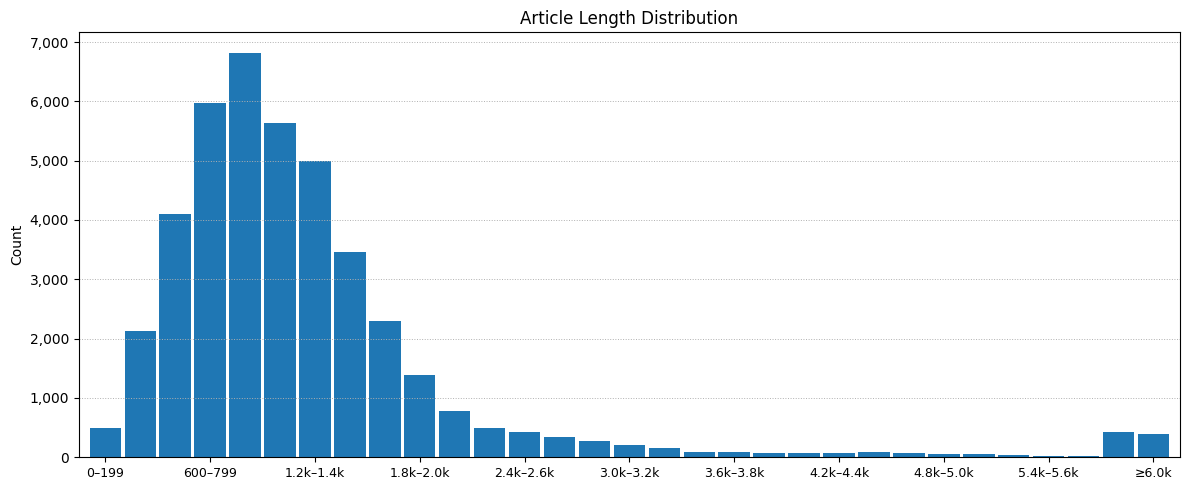

Note: 394 articles in the overflow bin (length ≥ 5,950). Bin size = 200.


In [6]:
# Step 1.1 · Bar chart of article length 
import numpy as np, pandas as pd, matplotlib.pyplot as plt, re
from matplotlib.ticker import FuncFormatter

# reuse df; load if missing
try:
    df
except NameError:
    df = pd.read_pickle("../data/processed/cleaned_articles.pkl").copy()

# ensure numeric length
if "length_num" not in df.columns:
    df["length_num"] = pd.to_numeric(
        df["length"].astype(str).str.extract(r"(\d+)")[0], errors="coerce"
    )

x = df["length_num"].dropna().astype(int)
if len(x) == 0:
    print("No numeric lengths to plot.")
else:
    # 1) clip long tail at 99th percentile (round up to nearest 50)
    cap = int(np.ceil(np.percentile(x, 99) / 50.0) * 50)

    # 2) adaptive bin so bars <= 30~35
    bin_size = 50
    while int(np.ceil(cap / bin_size)) > 30:
        bin_size *= 2

    # 3) counts + overflow (>= cap)
    bins = np.arange(0, cap + bin_size, bin_size)
    clipped = x.clip(upper=cap - 1)
    cats = pd.cut(clipped, bins=bins, include_lowest=True, right=True)
    counts = cats.value_counts().sort_index()
    overflow = int((x >= cap).sum())

    # labels helper -> use k-abbrev (e.g., 1.2k)
    def fmt_k(n): 
        return f"{n/1000:.1f}k" if n >= 1000 else f"{n}"
    labels = [f"{fmt_k(l)}–{fmt_k(r-1)}" for l, r in zip(bins[:-1], bins[1:])]
    if overflow > 0:
        counts = pd.concat([counts, pd.Series([overflow], index=[f"≥{fmt_k(cap)}"])])
        labels.append(f"≥{fmt_k(cap)}")

    # 4) draw with sparse ticks
    idx = np.arange(len(counts))
    fig, ax = plt.subplots(figsize=(12, 5))
    ax.bar(idx, counts.values, width=0.9)

    ax.set_title("Article Length Distribution")
    ax.set_ylabel("Count")

    # show ~8–10 x-tick labels max
    n_labels = min(10, len(labels))
    step = max(1, len(labels) // n_labels)
    tick_idx = idx[::step]
    ax.set_xticks(tick_idx)
    ax.set_xticklabels([labels[i] for i in tick_idx], rotation=0, fontsize=9)

    # y as 1,000 separators + light grid
    ax.yaxis.set_major_formatter(FuncFormatter(lambda v, p: f"{int(v):,}"))
    ax.yaxis.grid(True, linestyle=":", linewidth=0.7)
    plt.margins(x=0.01)
    plt.tight_layout()
    plt.show()

    if overflow > 0:
        print(f"Note: {overflow:,} articles in the overflow bin (length ≥ {cap:,}). Bin size = {bin_size}.")

<a id="11-findings-article-length"></a>
#### Findings — 1.1 Article length *(bin = 200 words; cap = 5,950; overflow = 394)*
- The distribution is **right-skewed**, with a clear mode around **~800–1,200 words** (the 800–999 and 1.0k–1.2k bins form the peak).
- **Very short pieces (<400 words)** are relatively uncommon; volumes ramp up quickly from **400** to **~1,200**.
- The **bulk of articles** fall in the **400–1,600** range, and the **vast majority** are **below 2,000 words**.
- Counts **decline steadily beyond ~3,200 words**, indicating a long but thin tail of long-form pieces.
- **Overflow (≥5,950 words): 394 articles (~≈1%)** are grouped into a single bin for readability.

[↰ Return to Top](#top)

<a id="12-consistency-check-length-vs-body-word-count"></a>
### 1.2 Consistency check: `length` vs. body word count
[↰ Return to Top](#top)

> **Context.** Sanity-check that the provided `length` aligns with the tokenized word count from `body`.

**Inputs:** `length_num` (parsed), `body` → `word_count`.  
**Method:** Compute relative error `|length_num − word_count| / word_count` and report the share within **±5%**.  
**Output:** Match rate + median absolute/relative differences; optionally print a few mismatched examples.


In [7]:
# Step 1.2 · Consistency check exactly as described (±5% + optional examples)
import re, numpy as np, pandas as pd

TOL = 0.05                 # ±5%
SHOW_EXAMPLE_ARTICLES = True

# Reuse df; load if missing
try:
    df
except NameError:
    df = pd.read_pickle("../data/processed/cleaned_articles.pkl").copy()

# Inputs: length_num (parsed), body -> word_count
if "length_num" not in df:
    df["length_num"] = pd.to_numeric(df["length"].astype(str).str.extract(r"(\d+)")[0], errors="coerce")

rx = re.compile(r"\b\w+\b", flags=re.UNICODE)
df["word_count"] = df["body"].apply(lambda s: len(rx.findall(s)) if isinstance(s, str) else 0)

# Relative error |length_num - word_count| / word_count
mask = df["length_num"].notna() & (df["word_count"] > 0)
rel_diff = (df.loc[mask, "length_num"] - df.loc[mask, "word_count"]).abs() / df.loc[mask, "word_count"]
abs_diff = (df.loc[mask, "length_num"] - df.loc[mask, "word_count"]).abs()

# Report
print(f"Rows checked: {mask.sum():,}")
print(f"Share within ±5%: {rel_diff.le(TOL).mean():.1%}")
print(f"Median abs diff: {int(abs_diff.median())} words")
print(f"Median rel diff: {rel_diff.median():.1%}")

#print a few mismatched examples
if SHOW_EXAMPLE_ARTICLES:
    examples = (
        df.loc[mask, ["title","section","length","length_num","word_count"]]
          .assign(rel_diff=rel_diff.values)
          .query("rel_diff > @TOL")
          .sort_values("rel_diff", ascending=False)
          .head(5)
    )
    if len(examples):
        with pd.option_context("display.max_colwidth", 120):
            print("\nExamples of mismatches (>±5%):")
            print(examples.to_string(index=False))

Rows checked: 41,148
Share within ±5%: 52.9%
Median abs diff: 48 words
Median rel diff: 4.7%

Examples of mismatches (>±5%):
                                                                                                                                                    title                                                 section  length  length_num  word_count  rel_diff
                                                                                                                                                WORLD CUP                              SPORTS; Pg. 1B; Sportsline    1302        1302         405  2.214815
                                                                                                                                       GRAFFITI ISN'T ART               EDITORIAL; LETTERS TO THE EDITOR; Pg. B-6     625         625         233  1.682403
                                                                                                                       

<a id="12-consistency-check-length-vs-body-word-count-findings"></a>
#### Findings — 1.2 Consistency check: `length` vs. body word count
- **Rows checked:** 41,148  
- **Share within ±5%:** **52.9%**  
- **Median absolute difference:** **48 words**  
- **Median relative difference:** **4.7%**

**Interpretation.** About half of the records agree closely (±5%). The typical gap is small (≈50 words / 4–5%), suggesting the two measures generally align. However, a non-trivial tail of mismatches remains.

**Patterns from top mismatches :**
- Cases where **`length_num` ≫ `word_count`** (e.g., 1302 vs 405; 625 vs 233; 1889 vs 756) likely indicate **partial/truncated bodies** or briefs/teasers captured in `body`.
- Cases where **`length_num` ≪ `word_count`** (e.g., 151 vs 1,219; 443 vs 3,042) suggest the **`length` field was misparsed or inconsistently defined** for some items (e.g., page codes like “Pg. H01” leaking digits into `length`, or publisher-specific length conventions).

<a id="2-sections-analysis"></a>
# 2. Sections Analysis
[↰ Return to Top](#top)


In [2]:
sections = (
    df["section"]
      .dropna()
      .astype(str)
      .str.strip()
      .loc[lambda s: s.ne("")]
    .unique()
)

for s in sorted(sections):
    print(s)

'Road less traveled'; Pg. 1G
,
.FOOD; Pg. D1
48 Hours; Pg. 6G
48 hours; Pg. 1G
; Inq Arts & Entertainment; Pg. 00
; Pg. A1
; Pg. A10
; Pg. A11
; Pg. A12
; Pg. A13
; Pg. A14
; Pg. A15
; Pg. A16
; Pg. A17
; Pg. A18
; Pg. A2
; Pg. A22
; Pg. A23
; Pg. A27
; Pg. A3
; Pg. A4
; Pg. A5
; Pg. A6
; Pg. A7
; Pg. A8
; Pg. A9
; Pg. AA1
; Pg. B1
; Pg. B2
; Pg. B3
; Pg. B4
; Pg. B5
; Pg. B6
; Pg. B7
; Pg. B8
; Pg. C3
; Pg. C5
; Pg. C6
; Pg. D1
; Pg. D12
; Pg. D15
; Pg. D2
; Pg. D3
; Pg. D4
; Pg. D5
; Pg. D7
; Pg. E1
; Pg. E2
; Pg. E8
; Pg. G1
; Pg. GO12
; Pg. GO15
; Pg. GO3
; Pg. GO5
; Pg. P8
; Pg. SA1
; Pg. SA2
; Pg. SA3
; Pg. SB1
; Pg. SB2
; Pg. SB4
; Pg. SB6
; Pg. SC1
; Pg. SC10
; Pg. SC16
; Pg. SC18
; Pg. SD1
; Pg. SE1
; Pg. SF10
; Pg. SF14
; Pg. SF18
; Pg. SF2
; Pg. SF3
; Pg. SF9
; Pg. SH2
; Pg. SPA1
; Pg. SPA10
; Pg. SPA5
; Pg. SPA6
; Pg. SPA7
; Pg. SPA8
; Pg. SPB10
; Pg. SPB4
; Pg. SPB5
; Pg. SPB6
; Pg. SPC6
; Pg. SPD6
; Pg. Z1
; Pg. Z2
; Pg. Z3
; Pg. Z4
; Pg. Z5
; Pg. Z6
; Pg. Z7
; Pg. Z8
; P

In [3]:
#Check for unique section names
from itertools import islice

sections_raw = df["section"].dropna().astype(str)

unique_raw = set(sections_raw)
print("Unique count (raw):", len(unique_raw))
list(islice(unique_raw, 20))  # show 20 samples

Unique count (raw): 12352


['',
 '; Pg. D7',
 'Section A; Column 0; Foreign Desk; Pg. 18; MONTREAL DISPATCH',
 'Section A; Column 0; Foreign Desk; Pg. 4; ADELAIDE JOURNAL',
 'EDITORIAL; Pg. 6A',
 'Section ST; Column 0; Style Desk; Pg. 2; CIRCA NOW',
 'Section A;; Section A; Page 8; Column 3; Foreign Desk; Column 3;',
 'Section A; Column 0; National Desk; Pg. 1; JACKSON JOURNAL',
 'Pg. A17; news',
 'Section 6;; Section 6; Page 14; Column 1; Magazine Desk; Column 1;; Biography',
 'Section E; PT2; Column 2; Leisure/Weekend Desk; Pg. 28; ART REVIEW',
 'Section A; Page 12, Column 3; National Desk',
 'Section C; Column 3; Business/Financial Desk; Pg. 8; MOST WANTED',
 'NATIONAL; THE ROAD TO THE WHITE HOUSE; Pg. A-14',
 'Section B; Column 0; The Arts/Cultural Desk; Pg. 16; MUSIC REVIEW',
 'ENTERTAINMENT; Pg. 3F',
 'ARTS & ENTERTAINMENT; COVER STORY: DANCE PREVIEW; Pg. W-12',
 'Pg. 5C',
 'Section A; Column 0; Politics; Pg. 25',
 'Section 1; ; Section 1;  Page 33;  Column 6;  Business/Financial Desk ; Column 6;']

In [4]:
# Clean NBSP and extra spaces
sections_clean = (
    sections_raw
      .str.replace("\xa0", " ", regex=False)
      .str.replace(r"\s+", " ", regex=True)
      .str.strip()
)

unique_clean = set(sections_clean)
print("Unique count (cleaned):", len(unique_clean))
list(islice(unique_clean, 20))  # show 20 samples after cleaning

Unique count (cleaned): 12055


['',
 '; Pg. D7',
 'Section A; Column 0; Foreign Desk; Pg. 18; MONTREAL DISPATCH',
 'Section A; Column 0; Foreign Desk; Pg. 4; ADELAIDE JOURNAL',
 'EDITORIAL; Pg. 6A',
 'Section ST; Column 0; Style Desk; Pg. 2; CIRCA NOW',
 'Section A;; Section A; Page 8; Column 3; Foreign Desk; Column 3;',
 'Section A; Column 0; National Desk; Pg. 1; JACKSON JOURNAL',
 'Pg. A17; news',
 'Section 6;; Section 6; Page 14; Column 1; Magazine Desk; Column 1;; Biography',
 'Section E; PT2; Column 2; Leisure/Weekend Desk; Pg. 28; ART REVIEW',
 'Section A; Page 12, Column 3; National Desk',
 'Section C; Column 3; Business/Financial Desk; Pg. 8; MOST WANTED',
 'NATIONAL; THE ROAD TO THE WHITE HOUSE; Pg. A-14',
 'Section B; Column 0; The Arts/Cultural Desk; Pg. 16; MUSIC REVIEW',
 'ENTERTAINMENT; Pg. 3F',
 'ARTS & ENTERTAINMENT; COVER STORY: DANCE PREVIEW; Pg. W-12',
 'Pg. 5C',
 'Section C; ; Section C; Page 28; Column 1; Weekend Desk ; Column 1; ; Review',
 'Section A; Column 0; Politics; Pg. 25']

In [5]:
import re

# 1) Make tokens (split by semicolon)
tokens = (
    sections_clean
        .loc[sections_clean.ne("")]        # drop empty rows
        .str.split(";")
        .explode()
        .str.strip()
        .loc[lambda s: s.ne("")]           # drop empty tokens
)

# 2) Drop obvious noise: pages/columns/sections etc.
noise_regex = re.compile(
    r"(?i)^("
    r"pg\.?\s*[A-Z0-9\-]+|"               # Pg. D03 / Pg. E-1 / Pg W-14
    r"page\s+\d+(?:,\s*column\s*\d+)?|"   # Page 3, Column 4
    r"col(?:umn)?\.?\s*\d+|"              # Column 2 / Col. 3
    r"section\s+[A-Z0-9]+|"               # Section A / Section MT / Section 1
    r"text|biography"
    r")$"
)

tokens_clean = (
    tokens
      .str.replace(r"_+$", "", regex=True)     # strip trailing underscores like "SPORTS_"
      .str.replace(r"\s+", " ", regex=True)    # normalize spaces
      .loc[lambda s: ~s.str.match(noise_regex)]
)



# Normalize trailing punctuation so "arts & entertainment," == "arts & entertainment"
tokens_norm = (
    tokens_clean
      .str.replace(r"[,\.;]+$", "", regex=True)   # drop trailing , . ;
      .str.replace(r"\s+", " ", regex=True)       # normalize inner spaces
      .str.strip()
      .loc[lambda s: s.ne("")]                    # drop empties after trim
)

# Case-insensitive counting
canon = tokens_norm.str.casefold()
top200 = canon.value_counts().head(50)
top200

section
national desk                           3369
news                                    3038
metropolitan desk                       2475
foreign desk                            2342
opinion                                 2180
editorial desk                          1610
review                                  1463
us                                      1408
book review desk                        1183
politics                                1091
editorial                               1064
the arts/cultural desk                  1032
national                                 995
arts and leisure desk                    968
business                                 912
world                                    869
arts & entertainment                     768
life                                     752
magazine desk                            723
movies, performing arts/weekend desk     714
local                                    580
sports                                   530
bu

In [8]:
import re
import pandas as pd

# 10 buckets
CATEGORIES = [
    "World/International",
    "US/National",
    "Metro/Local",
    "Business/Finance",
    "Sports",
    "Arts/Culture",
    "Lifestyle",
    "Opinion/Editorial/Letters",
    "books/podcast",
    "Science/Health/Tech",
]

# ======================
# Noise (filter out before classification) 
# ======================
NOISE_RE = re.compile(
    r"(?i)^(?:"
    r"column\s*\d+|"                          # column 0/1/2...
    r"pg$|"                                   # bare 'pg'
    r"pg\.?\s*(?:[A-Z]?-?[0-9]+[A-Z]*|web)|"  # pg. 1a / pg. a-1 / pg. 3 / pg. web
    r"page\s+\d+|"                            # page 1
    r"section(?:\s+[A-Z0-9]+)?|"              # section / section A / section 1
    r"asection|"                              # asection
    r"front[_ ]page|web|"                     # front_page / front page / web
    r"submitted content|cover story|specialsections|fence post|"  # packaging
    r"timeout|time\s*out!?|go!|"              # time out!, go!
    r"part\s+\d+"                             # part 1/2...
    r")$"
)

# ======================
# Canonicalization rules
# ======================
CANON_REPL = [
    (re.compile(r"\bliesure\b", flags=re.I), "leisure"),
    (re.compile(r"\bweschester\b", flags=re.I), "westchester"),
    (re.compile(r"[_]+$", flags=re.I), ""),         # drop trailing underscores (nation_/political_/news_)
    (re.compile(r"[–—]", flags=re.I), "-"),         # normalize en/em-dash
    (re.compile(r"\s+/\s+", flags=re.I), "/"),      # normalize spaces around '/'
    (re.compile(r"\s*&\s*", flags=re.I), " & "),    # normalize & spacing
    (re.compile(r"\s+", flags=re.I), " "),          # collapse spaces
]

LEAD_QUOTES_RE  = re.compile(r'^[\"\'“”‘’]+')       # strip leading quotes
TRAIL_PUNCT_RE  = re.compile(r'[,\.;:!\?\"\'“”‘’]+$')  # strip trailing punctuation incl. quotes

def normalize_token(tok: str) -> str:
    s = str(tok)
    s = LEAD_QUOTES_RE.sub("", s)
    s = TRAIL_PUNCT_RE.sub("", s).strip()
    for patt, repl in CANON_REPL:
        s = patt.sub(repl, s)
    return s.casefold()

# ======================
# DESK_MAP (desk first)
# ======================
DESK_MAP = {
    # Metro / Local
    "metropolitan desk": "Metro/Local",
    "nyregion": "Metro/Local",
    "new jersey weekly desk": "Metro/Local",
    "long island weekly desk": "Metro/Local",
    "connecticut weekly desk": "Metro/Local",
    "westchester weekly desk": "Metro/Local",
    "the city weekly desk": "Metro/Local",
    "pennsylvania voters guide": "Metro/Local",

    # World / International
    "foreign desk": "World/International",

    # US / National
    "national desk": "US/National",

    # Business / Finance
    "business/financial desk": "Business/Finance",
    "financial desk": "Business/Finance",
    "money and business/financial desk": "Business/Finance",
    "personal investing supplement desk": "Business/Finance",

    # Sports
    "sports desk": "Sports",

    # Arts / Culture
    "the arts/cultural desk": "Arts/Culture",
    "arts and leisure desk": "Arts/Culture",
    "arts & leisure desk": "Arts/Culture",
    "arts & ideas/cultural desk": "Arts/Culture",
    "cultural desk": "Arts/Culture",
    "cultural desk - summertimes supplement": "Arts/Culture",
    "leisure/weekend desk": "Arts/Culture",
    "weekend desk": "Arts/Culture",
    "movies, performing arts/weekend desk": "Arts/Culture",
    "dining, dining out/cultural desk": "Arts/Culture",

    # Lifestyle
    "style desk": "Lifestyle",
    "real estate desk": "Lifestyle",
    "travel desk": "Lifestyle",
    "dining in, dining out/style desk": "Lifestyle",
    "dining in, dining out / style desk": "Lifestyle",
    "house & home/style desk": "Lifestyle",
    "living desk": "Lifestyle",
    "home desk": "Lifestyle",
    "society desk": "Lifestyle",
    "magazine desk": "Lifestyle",

    # Opinion / Editorial / Letters
    "editorial desk": "Opinion/Editorial/Letters",
    "sunday review desk": "Opinion/Editorial/Letters",
    "week in review desk": "Opinion/Editorial/Letters",

    # books / podcast
    "book review desk": "books/podcast",

    # Science / Tech / Health
    "science desk": "Science/Health/Tech",
}

# ======================
# KEYWORD_MAP (lowercase keys
# ======================
KEYWORD_MAP = {
    # US / National
    "us": "US/National",
    "national": "US/National",
    "politics": "US/National",
    "the upshot": "US/National",
    "upshot": "US/National",
    "nytnow": "US/National",
    "minnesota poll": "US/National",
    "state": "US/National",
    "nation": "US/National",
    "national weekly": "US/National",

    # World / International
    "world": "World/International",
    "europe": "World/International",
    "china": "World/International",
    "nation & world extra": "World/International",
    "infoplus: world up close": "World/International",
    "nation world": "World/International",
    "nation & world": "World/International",     

    # Metro / Local
    "local": "Metro/Local",
    "neighbor": "Metro/Local",
    "neighbors": "Metro/Local",
    "philadelphia": "Metro/Local",
    "south jersey": "Metro/Local",
    "new jersey": "Metro/Local",
    "connecticut": "Metro/Local",
    "region": "Metro/Local",
    "the region": "Metro/Local",
    "philly & region": "Metro/Local",
    "dayton": "Metro/Local",
    "beavercreek fairborn and xenia": "Metro/Local",
    "huber heights riverside dayton and vandalia": "Metro/Local",
    "west montgomery county": "Metro/Local",
    "manayunk": "Metro/Local",
    "southwest": "Metro/Local",
    "the gazette": "Metro/Local",
    "city & region": "Metro/Local",
    "metro": "Metro/Local",
    "local news philadelphia & its suburbs": "Metro/Local",
    "neighbors montgomery": "Metro/Local",       
    "metro today": "Metro/Local",                

    # Business / Finance
    "business": "Business/Finance",
    "business wire": "Business/Finance",         
    "marketplace": "Business/Finance",           
    "money": "Business/Finance",
    "biz ledger": "Business/Finance",
    "classified": "Business/Finance",
    "classifieds": "Business/Finance",
    "job market": "Business/Finance",
    "your-money": "Business/Finance",
    "retirement": "Business/Finance",
    "budgets": "Business/Finance",
    "philadelphia business":"Business/Finance",

    # Sports
    "sports": "Sports",
    "sports-high schools": "Sports",
    "sportsweekend": "Sports",
    "sportsxtra": "Sports",

    # Arts / Culture
    "arts & entertainment": "Arts/Culture",
    "arts and entertainment": "Arts/Culture",    
    "arts": "Arts/Culture",
    "p-com ent. entertainment":"Arts/Culture",
    "movies": "Arts/Culture",
    "movie review": "Arts/Culture",
    "television": "Arts/Culture",
    "variety": "Arts/Culture",
    "entertainment": "Arts/Culture",
    "theater": "Arts/Culture",
    "features magazine: entertainment": "Arts/Culture",
    "features magazine / entertainment": "Arts/Culture",  
    "features entertainment": "Arts/Culture",             
    "features arts & entertainment": "Arts/Culture",      
    "inq arts & entertainment": "Arts/Culture",
    "museums": "Arts/Culture",
    "screening room": "Arts/Culture",
    "history extra": "Arts/Culture",
    "play": "Arts/Culture",
    "watching": "Arts/Culture",
    "life & arts": "Arts/Culture",    

       # LifeStyle
    "life": "LifeStyle",
    "lifestyles": "LifeStyle",
    "lifestyle": "LifeStyle",
    "travel": "LifeStyle",
    "magazine": "LifeStyle",
    "style": "LifeStyle",
    "dining": "LifeStyle",
    "features weekend": "LifeStyle",
    "weekender": "LifeStyle",
    "escapes": "LifeStyle",
    "food": "LifeStyle",
    "suburban living": "LifeStyle",
    "real estate": "LifeStyle",
    "t magazine": "LifeStyle",
    "t: women's fashion magazine": "LifeStyle",
    "t: men's fashion magazine": "LifeStyle",
    "t: travel magazine": "LifeStyle",
    "features magazine": "LifeStyle",
    "features": "LifeStyle",
    "features lifestyle": "LifeStyle",
    "features image": "LifeStyle",
    "features magazine: lifestyle": "LifeStyle",
    "features magazine: home & design": "LifeStyle",
    "features home & design": "LifeStyle",
    "features travel": "LifeStyle",
    "thursday styles": "LifeStyle",
    "tstyle": "LifeStyle",
    "styles of the times": "LifeStyle",
    "parenting": "LifeStyle",
    "going places": "LifeStyle",
    "what to do": "LifeStyle",
    "leisure": "LifeStyle",
    "then & now": "LifeStyle",
    "summer times supplement": "LifeStyle",
    "spring times supplement": "LifeStyle",
    "live life love": "LifeStyle",
    "key magazine": "LifeStyle",
    "craig laban s ultimate dining": "LifeStyle",
    "road less traveled": "LifeStyle",
    "automobiles": "LifeStyle",
    "motoring": "LifeStyle",
    "cars": "LifeStyle",
    "auto showcase": "LifeStyle",
    "auto": "LifeStyle",
    "realestate": "LifeStyle",
    "t-magazine": "LifeStyle",
    "fashion": "LifeStyle",
    "sophisticated traveler magazine": "LifeStyle",
    "variety / freetime": "LifeStyle",
    "freetime": "LifeStyle",

    # Opinion / Editorial / Letters
    "opinion": "Opinion/Editorial/Letters",
    "opinions": "Opinion/Editorial/Letters",               
    "editorial": "Opinion/Editorial/Letters",
    "op-ed": "Opinion/Editorial/Letters",
    "oped": "Opinion/Editorial/Letters",
    "op-ed columnist": "Opinion/Editorial/Letters",
    "op-ed contributor": "Opinion/Editorial/Letters",
    "letters": "Opinion/Editorial/Letters",
    "letter": "Opinion/Editorial/Letters",
    "letters to the editor": "Opinion/Editorial/Letters",
    "currents-editorial": "Opinion/Editorial/Letters",
    "community voices": "Opinion/Editorial/Letters",
    "sunday review": "Opinion/Editorial/Letters",          
    "ideas & voices": "Opinion/Editorial/Letters",         
    "ideas voices": "Opinion/Editorial/Letters",           
    "p-com opinion": "Opinion/Editorial/Letters",          

    # books / podcast
    "books": "books/podcast",
    "transcript": "books/podcast",
    "podcast": "books/podcast",
    "podcasts": "books/podcast",

    # Science / Tech / Health
    "well": "Science/Health/Tech",
    "technology": "Science/Health/Tech",
    "health, science, medicine & technology": "Science/Health/Tech",
    "science, medicine, technology": "Science/Health/Tech",
    "ohiotech": "Science/Health/Tech",
    "health": "Science/Health/Tech",
}

# ======================
# Classifier: Desk-first, then Keyword , else None
# ======================
def classify_section(section_text: str) -> str | None:
    if pd.isna(section_text) or not str(section_text).strip():
        return None

    tokens = [t.strip() for t in str(section_text).split(";") if t.strip()]
    if not tokens:
        return None

    desk_hits, kw_hits = set(), set()

    for t in tokens:
        # filter layout/packaging noise
        if NOISE_RE.match(t.strip()):
            continue
        k = normalize_token(t)
        if not k:
            continue
        if k in DESK_MAP:
            desk_hits.add(DESK_MAP[k])
        if k in KEYWORD_MAP:
            kw_hits.add(KEYWORD_MAP[k])

    # Desk-first
    if len(desk_hits) == 1:
        return next(iter(desk_hits))
    if len(desk_hits) > 1:
        return None   # conflicting desks → abstain

    # Keyword fallback (books/podcast priority)
    if len(kw_hits) >= 1:
        if "books/podcast" in kw_hits:
            return "books/podcast"
        return next(iter(kw_hits)) if len(kw_hits) == 1 else None

    return None

# ======================
# Apply 
# ======================
df["section_clean"] = df["section"].astype(str).apply(normalize_token)
df["category"] = df["section_clean"].apply(classify_section)



In [9]:
#quick checks:
coverage = df["category"].notna().mean()
df["category"].value_counts(dropna=False).head(20)

category
US/National                  6235
Arts/Culture                 6103
None                         5797
Opinion/Editorial/Letters    5449
Metro/Local                  5379
World/International          3269
LifeStyle                    2365
Style/Life/Fashion           1943
Business/Finance             1935
books/podcast                1702
Sports                        894
Science/Health/Tech            77
Name: count, dtype: int64

In [130]:
import re
import pandas as pd

# 1) none
uncat = (
    df.loc[df["category"].isna(), "__section_input__"]
      .dropna()
      .astype(str)
      .str.strip()
)

print("Uncategorized rows:", len(uncat))

# 2) None x section 
full_section_top60 = uncat.value_counts().head(60)
print("\nTop 60 full sections in None:")
display(full_section_top60)



# 3) NEWS related
NEWS_LIKE_RE = re.compile(r"^(news|main news|other news|news with a view|news editorial)\b", re.I)
is_news_like = tokens_none_clean.str.match(NEWS_LIKE_RE)
share_news_like = float(is_news_like.mean()) * 100.0

print(f"\nShare of remaining tokens that are NEWS-like: {share_news_like:.2f}%")
print("Top NEWS-like tokens:")
display(tokens_none_clean[is_news_like].value_counts().head(20))

print("\nTop non-NEWS tokens (if any left):")
display(tokens_none_clean[~is_news_like].value_counts().head(20))

Uncategorized rows: 5797

Top 60 full sections in None:


__section_input__
NEWS; Pg. 1A                 285
NEWS;                        224
BRIEFING                     198
NEWS; Pg. A1                 176
NEWS; Pg. 0                  162
NEWS; Pg. 1B                 152
NEWS; Pg. 1                   99
NEWS; Pg. 8A                  75
ASECTION; Pg. A-1             70
NEWS; Pg. 7A                  70
NEWS; Pg. 3A                  65
NEWS; Pg. 6A                  64
NEWS                          61
MAIN NEWS; Pg. A1             58
NEWS; Pg. 5A                  57
NEWS; Pg. 10A                 56
NEWS; Pg. 4A                  55
NEWS; Pg. 8                   52
NEWS,                         52
NEWS; Pg. 10                  45
News; Pg. 1B                  43
TIMEOUT; Pg. 0                42
NEWS; Pg. 12                  41
NEWS; Pg. 14                  37
News; Pg. 1A                  37
NEWS;; COVER STORY            36
LEARNING                      33
NEWS; Pg. 9A                  33
News;                         32
NEWS; Pg. 2A             


Share of remaining tokens that are NEWS-like: 55.84%
Top NEWS-like tokens:


__section_input__
news                2972
main news             84
news with a view      11
other news             1
news editorial         1
Name: count, dtype: int64


Top non-NEWS tokens (if any left):


__section_input__
briefing                     198
forum                         76
currents                      70
political_                    46
learning                      42
variety / freetime            42
usa today                     36
national weekly               34
debate                        32
cti                           31
p-com news                    30
freetime                      28
news_                         25
p-com news politics           25
education life supplement     23
features travel               22
vita.mn                       22
pg                            21
go!                           21
p-com ent. entertainment      21
Name: count, dtype: int64

#### New Dataset with category

In [131]:
df.columns.tolist()

['title',
 'publisher',
 'date',
 'section',
 'body',
 'length',
 'letters_flag',
 'country_flag',
 'foreign_countries',
 'us_mentions',
 'source_file',
 'publisher_raw',
 'category',
 '__section_input__']

In [132]:
keep = [
    "title", "publisher", "date", "section", "body", "length",
    "letters_flag", "country_flag", "foreign_countries", "us_mentions",
    "source_file", "publisher_raw", "category"
]
df_new = df.loc[:, keep].copy()

out_path = "dataset_for_analysis.pkl"
df_new.to_pickle(out_path)
print(f"Saved: {out_path}  |  shape={df_new.shape}")
print("Columns:", df_new.columns.tolist())
print("\nHead preview:")
print(df_new.head(3))

Saved: dataset_for_analysis.pkl  |  shape=(41148, 13)
Columns: ['title', 'publisher', 'date', 'section', 'body', 'length', 'letters_flag', 'country_flag', 'foreign_countries', 'us_mentions', 'source_file', 'publisher_raw', 'category']

Head preview:
                                                                         title  \
0                            A Well-Documented Childhood. A Very Private Life.   
1  These were the big stories in arts and culture in the Dayton region in 2024   
2                                              She Exalted The Beauty Of Dance   

         publisher        date  \
0   New York Times  2024-12-31   
1  Other publisher  2024-12-31   
2   New York Times  2024-12-31   

                                                            section  \
0                        Section A; Column 0; National Desk; Pg. 16   
1                                                      WHAT TO KNOW   
2  Section C; Column 0; The Arts/Cultural Desk; Pg. 1; AN APPRAISAL   


 ## 3. Analysis on Category & length

In [133]:
import pandas as pd

df_new = pd.read_pickle("dataset_for_analysis.pkl")

In [121]:
import pandas as pd

pd.set_option("display.max_colwidth", 80)
cols = ["title","publisher","date","category","section","length","country_flag"]
view_cols = [c for c in cols if c in df_new.columns]

print("Preview columns:", view_cols)
print(df_new[view_cols].head(10).to_string(index=False))

Preview columns: ['title', 'publisher', 'date', 'category', 'section', 'length', 'country_flag']
                                                                                                                                                                                                   title       publisher       date                  category                                                                         section  length country_flag
                                                                                                                                                       A Well-Documented Childhood. A Very Private Life.  New York Times 2024-12-31               US/National                                      Section A; Column 0; National Desk; Pg. 16    1209         BOTH
                                                                                                                             These were the big stories in arts and culture in the Dayton region 

                           avg_length     n
category                                   
Style/Life/Fashion             1910.6  4308
books/podcast                  1528.6  1702
Science/Health/Tech            1510.3    77
US/National                    1314.6  6235
Business/Finance               1226.6  1935
Arts/Culture                   1193.8  6103
World/International            1168.3  3269
Sports                         1149.5   894
Metro/Local                    1113.2  5379
Opinion/Editorial/Letters      1044.2  5449
NaN                            1005.8  5797


<Figure size 900x500 with 0 Axes>

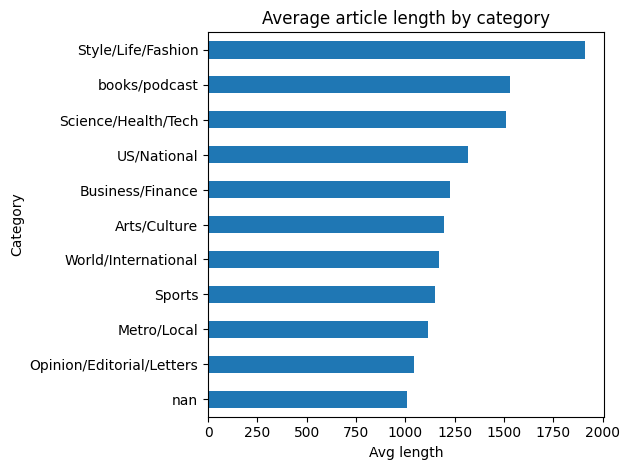

In [134]:
import pandas as pd
import matplotlib.pyplot as plt

cat_len = (
   df_new.groupby("category", dropna=False, observed=False)
         .agg(avg_length=("length","mean"), n=("title","size"))
         .sort_values("avg_length", ascending=False)
)
cat_len["avg_length"] = cat_len["avg_length"].round(1)
print(cat_len)

# barchart
plt.figure(figsize=(9, 5))
cat_len.sort_values("avg_length").plot(kind="barh", y="avg_length", legend=False)
plt.title("Average article length by category")
plt.xlabel("Avg length")
plt.ylabel("Category")
plt.tight_layout()
plt.show()

category                                Arts/Culture  Business/Finance  \
The New York Times                            1280.1            1423.8   
The Philadelphia Inquirer                     1115.5             882.6   
Pittsburgh Post-Gazette (Pennsylvania)         989.5            1000.3   
Chicago Daily Herald                           790.0             915.1   
Star Tribune (Minneapolis, MN)                 821.1             990.3   
USA TODAY                                        NaN            1099.8   
Pittsburgh Post-Gazette                        906.0            1105.1   
Dayton Daily News (Ohio)                       776.9             654.1   
USA Today                                        NaN            1212.8   
The New York Times Blogs                       599.1            1745.5   

category                                Metro/Local  \
The New York Times                           1189.1   
The Philadelphia Inquirer                     942.4   
Pittsburgh Post-Gaze

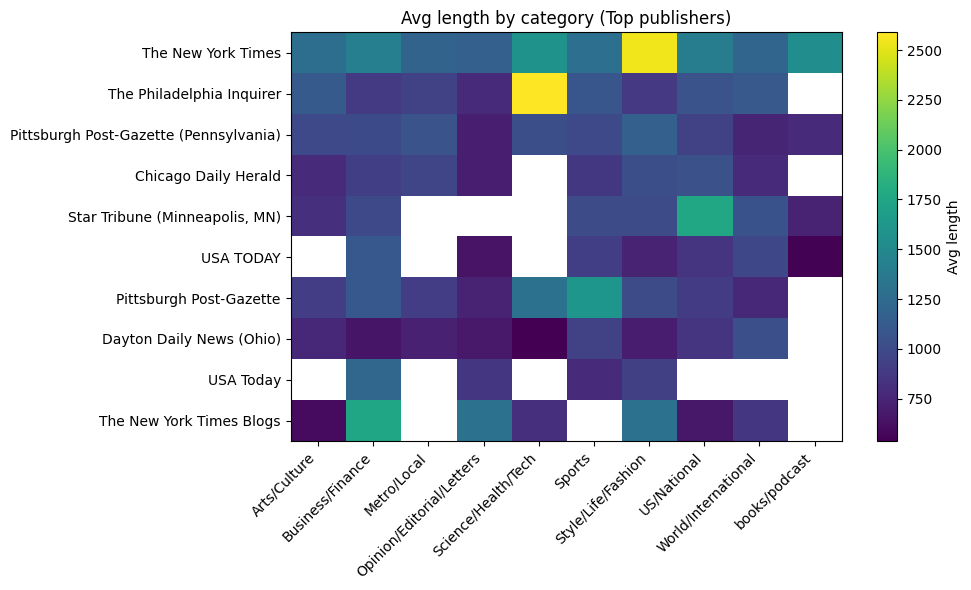

In [135]:
pub_cat_len = (
    df_new.groupby(["publisher_raw","category"], dropna=False)
      .agg(avg_length=("length","mean"), n=("title","size"))
      .reset_index()
)

# pivot table（row：publisher_raw；column：category；value：avg length）
pivot_len = pub_cat_len.pivot_table(
    index="publisher_raw", columns="category", values="avg_length"
).round(1)

# top 10 publisher
top_pub = (df_new["publisher_raw"].value_counts().head(10).index.tolist())
pivot_len_top = pivot_len.loc[pd.Index(top_pub).intersection(pivot_len.index)]
print(pivot_len_top)

plt.figure(figsize=(10, 6))
m = pivot_len_top.values
plt.imshow(m, aspect="auto")
plt.colorbar(label="Avg length")
plt.yticks(ticks=np.arange(len(pivot_len_top.index)), labels=pivot_len_top.index)
plt.xticks(ticks=np.arange(len(pivot_len_top.columns)), labels=pivot_len_top.columns, rotation=45, ha="right")
plt.title("Avg length by category (Top publishers)")
plt.tight_layout()
plt.show()

 ## 4. Analysis on Category & country_flag

In [136]:
# Cross-tab: category × country_flag (counts)
ct = pd.crosstab(df_new["category"], df_new["country_flag"])
print("Raw counts:\n", ct.head(20))

# Row-normalized shares (% within each category)
row_pct = ct.div(ct.sum(axis=1), axis=0).mul(100).round(1)
print("\nWithin-category % shares:\n", row_pct.head(20))


Raw counts:
 country_flag               BOTH  FOREIGN_ONLY  NONE  US_ONLY
category                                                    
Arts/Culture               2778           477   606     2242
Business/Finance            796            71    87      981
Metro/Local                1528           109   485     3257
Opinion/Editorial/Letters  1927           197   330     2995
Science/Health/Tech          39             3     1       34
Sports                      411            51    43      389
Style/Life/Fashion         2128           267   303     1610
US/National                2348            85   140     3662
World/International        1931          1092    88      158
books/podcast               884            72    74      672

Within-category % shares:
 country_flag               BOTH  FOREIGN_ONLY  NONE  US_ONLY
category                                                    
Arts/Culture               45.5           7.8   9.9     36.7
Business/Finance           41.1           3.

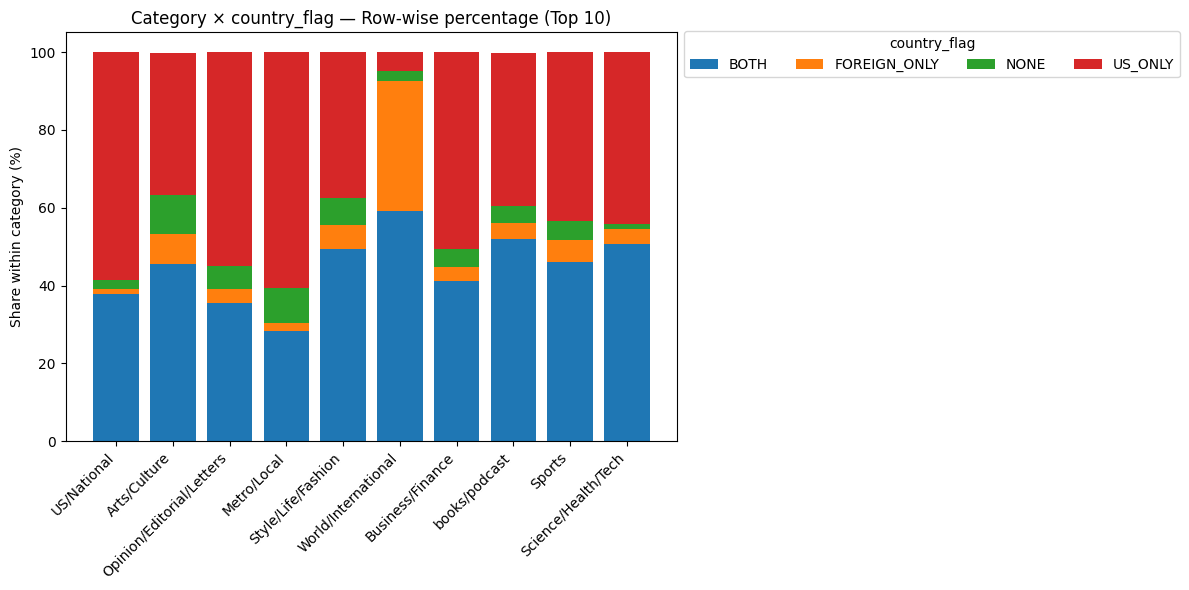

In [137]:
# --- Stacked % bar chart: category × country_flag ---
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# 2) Choose 10 categories by size for readability
TOP_N = 10
cat_order = ct.sum(axis=1).sort_values(ascending=False).index[:TOP_N]
row_pct_top = row_pct.loc[cat_order]

# 3) Plot stacked percentages
plt.figure(figsize=(12, 6))
x = np.arange(len(row_pct_top))
bottom = np.zeros(len(row_pct_top))

for col in row_pct_top.columns:
    vals = row_pct_top[col].values
    plt.bar(x, vals, bottom=bottom, label=col)
    bottom += vals

plt.xticks(x, row_pct_top.index, rotation=45, ha="right")
plt.ylabel("Share within category (%)")
plt.title("Category × country_flag — Row-wise percentage (Top {})".format(TOP_N))
plt.legend(title="country_flag", ncol=4, bbox_to_anchor=(1, 1.02), loc="upper left")
plt.tight_layout()
plt.show()